In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# raw GitHub link to the Excel file
url = "https://raw.githubusercontent.com/SAMKURA/Statistic/main/agrofood_co2_emission.xlsx"

# read the Excel file into a DataFrame
df = pd.read_excel(url)


In [53]:
# 3. HANDLE DUPLICATES
# -------------------------------
print("\nChecking duplicates...")
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove full duplicates
df = df.drop_duplicates()

print("Duplicates removed.")
print("New shape:", df.shape)

# -------------------------------
# 4. HANDLE MISSING VALUES
# -------------------------------

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())
print("\nMissing Percentage:")
print((df.isnull().mean()*100).round(2))


Checking duplicates...
Number of duplicate rows: 0
Duplicates removed.
New shape: (6965, 31)

Missing Values Before Cleaning:
Area                                  0
Year                                  0
Savanna fires                        31
Forest fires                         93
Crop Residues                      1389
Rice Cultivation                      0
Drained organic soils (CO2)           0
Pesticides Manufacturing              0
Food Transport                        0
Forestland                          493
Net Forest conversion               493
Food Household Consumption          473
Food Retail                           0
On-farm Electricity Use               0
Food Packaging                        0
Agrifood Systems Waste Disposal       0
Food Processing                       0
Fertilizers Manufacturing             0
IPPU                                743
Manure applied to Soils             928
Manure left on Pasture                0
Manure Management                

In [54]:
from sklearn.impute import SimpleImputer
# 4.1 Drop columns with >50% missing values
# -------------------------------
threshold = 0.5
df = df.loc[:, df.isnull().mean() < threshold]

print("\nColumns with >50% missing values removed.")
print("New shape:", df.shape)

# -------------------------------
# 4.2 Separate numeric and categorical columns
# -------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

# -------------------------------
# 4.3 Impute Numeric Columns (Median)
# -------------------------------
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
# -------------------------------
# 4.4 Impute Categorical Columns (Most Frequent)
# -------------------------------
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# -------------------------------
# 5. OPTIONAL: REMOVE OUTLIERS (Z-score method)
# -------------------------------
from scipy import stats

z_scores = np.abs(stats.zscore(df[numeric_cols]))
df = df[(z_scores < 3).all(axis=1)]

print("\nOutliers removed (Z-score > 3).")
print("New shape:", df.shape)

# -------------------------------
# 6. FINAL CHECK
# -------------------------------
print("\nFinal Duplicate Check:", df.duplicated().sum())
print("Final Missing Values:")
print(df.isnull().sum())


Columns with >50% missing values removed.
New shape: (6965, 31)

Missing Values After Cleaning:
Area                               0
Year                               0
Savanna fires                      0
Forest fires                       0
Crop Residues                      0
Rice Cultivation                   0
Drained organic soils (CO2)        0
Pesticides Manufacturing           0
Food Transport                     0
Forestland                         0
Net Forest conversion              0
Food Household Consumption         0
Food Retail                        0
On-farm Electricity Use            0
Food Packaging                     0
Agrifood Systems Waste Disposal    0
Food Processing                    0
Fertilizers Manufacturing          0
IPPU                               0
Manure applied to Soils            0
Manure left on Pasture             0
Manure Management                  0
Fires in organic soils             0
Fires in humid tropical forests    0
On-farm energy 

In [55]:
# 1. Clean column names (removes leading/trailing spaces if any)
df.columns = df.columns.str.strip()

# 2. Defining variables STRICTLY as per your dataset names
target_var = 'Food Household Consumption'

production_group = [
    'Fertilizers Manufacturing',
    'Manure Management',
    'Rice Cultivation',
    'Crop Residues'  # Removed underscore to match your original list
]

supply_chain_group = [
    'Food Processing',
    'Food Transport',
    'Food Retail',
    'Food Packaging'
]

# 3. Safe Extraction
try:
    X_production = df[production_group]
    X_supply_chain = df[supply_chain_group]
    y = df[target_var]
    print("Success: All variables found and grouped.")
except KeyError as e:
    print(f"Error: One or more columns are missing: {e}")
    # Run this to see what columns are actually in your file:
    # print(df.columns.tolist())

Success: All variables found and grouped.


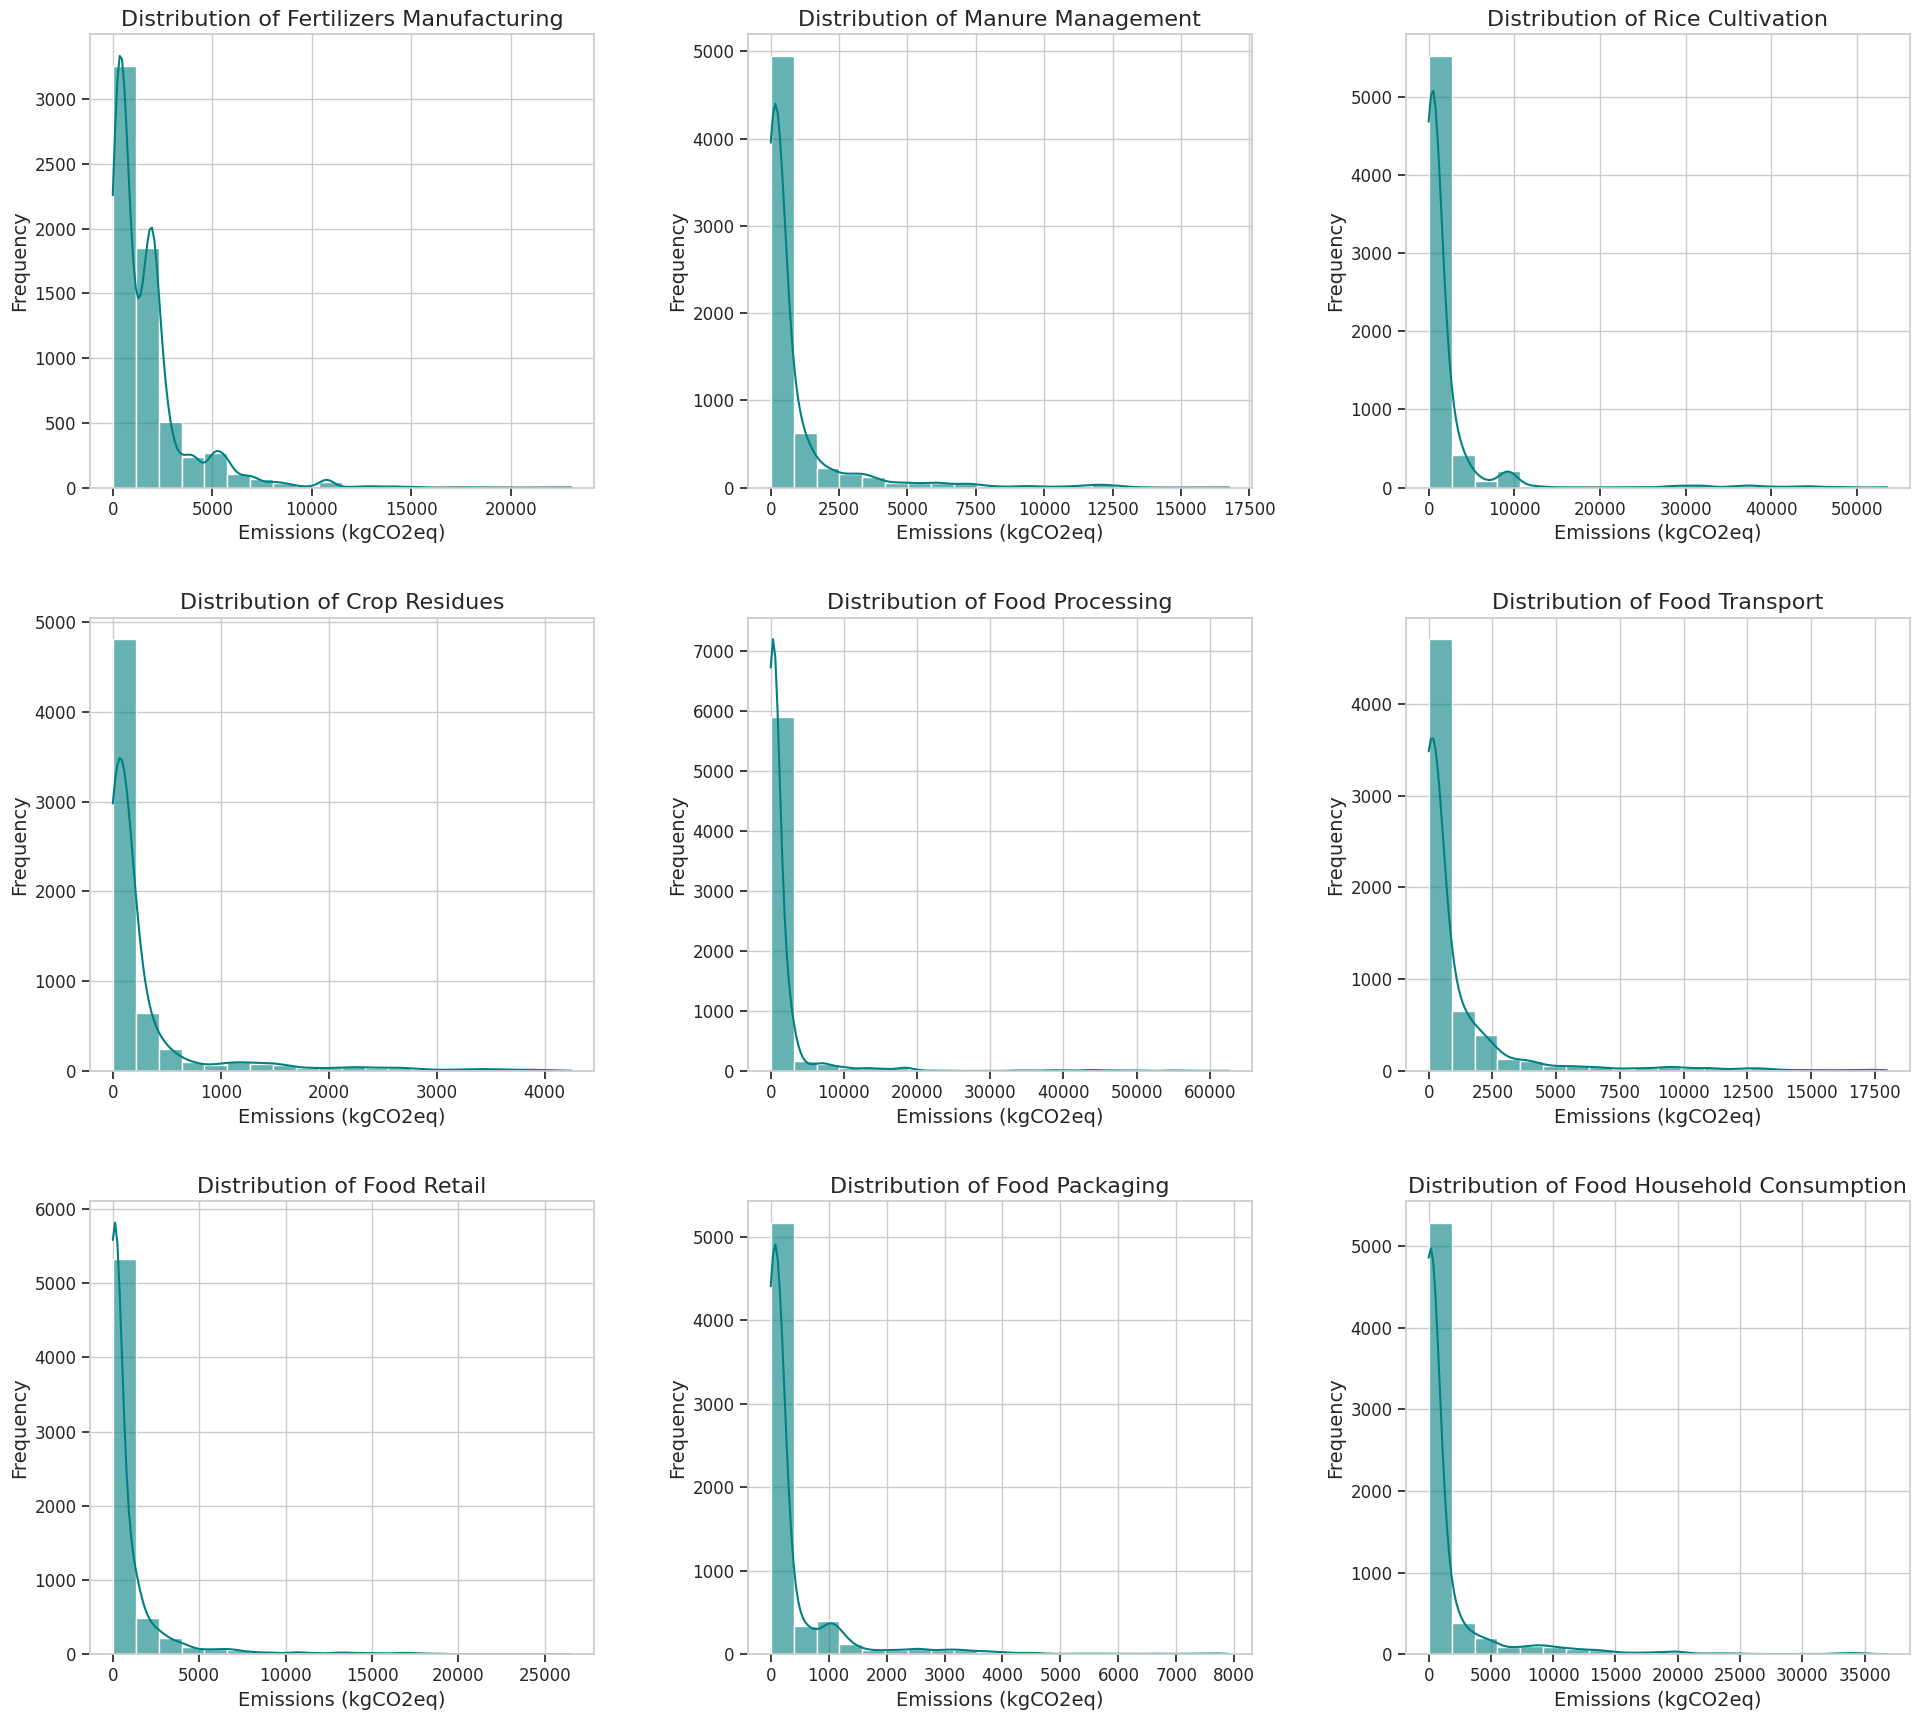

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the combined list of all variables for plotting (from previous step)
all_vars = production_group + supply_chain_group + [target_var]

# Set a uniform size for axes labels and titles, and enable a grid
sns.set_theme(style="whitegrid", rc={"axes.labelcolor": ".15", "xtick.bottom": True, "ytick.left": True})

# Step 1: Initialize a large figure to ensure all elements have space
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten() # Flatten 3x3 array into a 1D list for easier iteration

# Step 2: Loop to create each individual plot
for i, var in enumerate(all_vars):

    # Create the histogram and KDE on the current subplot axis
    sns.histplot(df[var], bins=20, kde=True, color='teal', ax=axes[i], alpha=0.6)

    # Strictly define titles and labels for readability
    axes[i].set_title(f'Distribution of {var}', fontsize=16)
    axes[i].set_xlabel('Emissions (kgCO2eq)', fontsize=14)
    axes[i].set_ylabel('Frequency', fontsize=14
    )

    # Refine tick parameters to ensure they are legible
    axes[i].tick_params(axis='both', labelsize=12)

# Step 3: Automatically adjust the layout
plt.tight_layout(pad=3.0) # Adjusts padding between subplots

# Display only the refined graphs
plt.show()

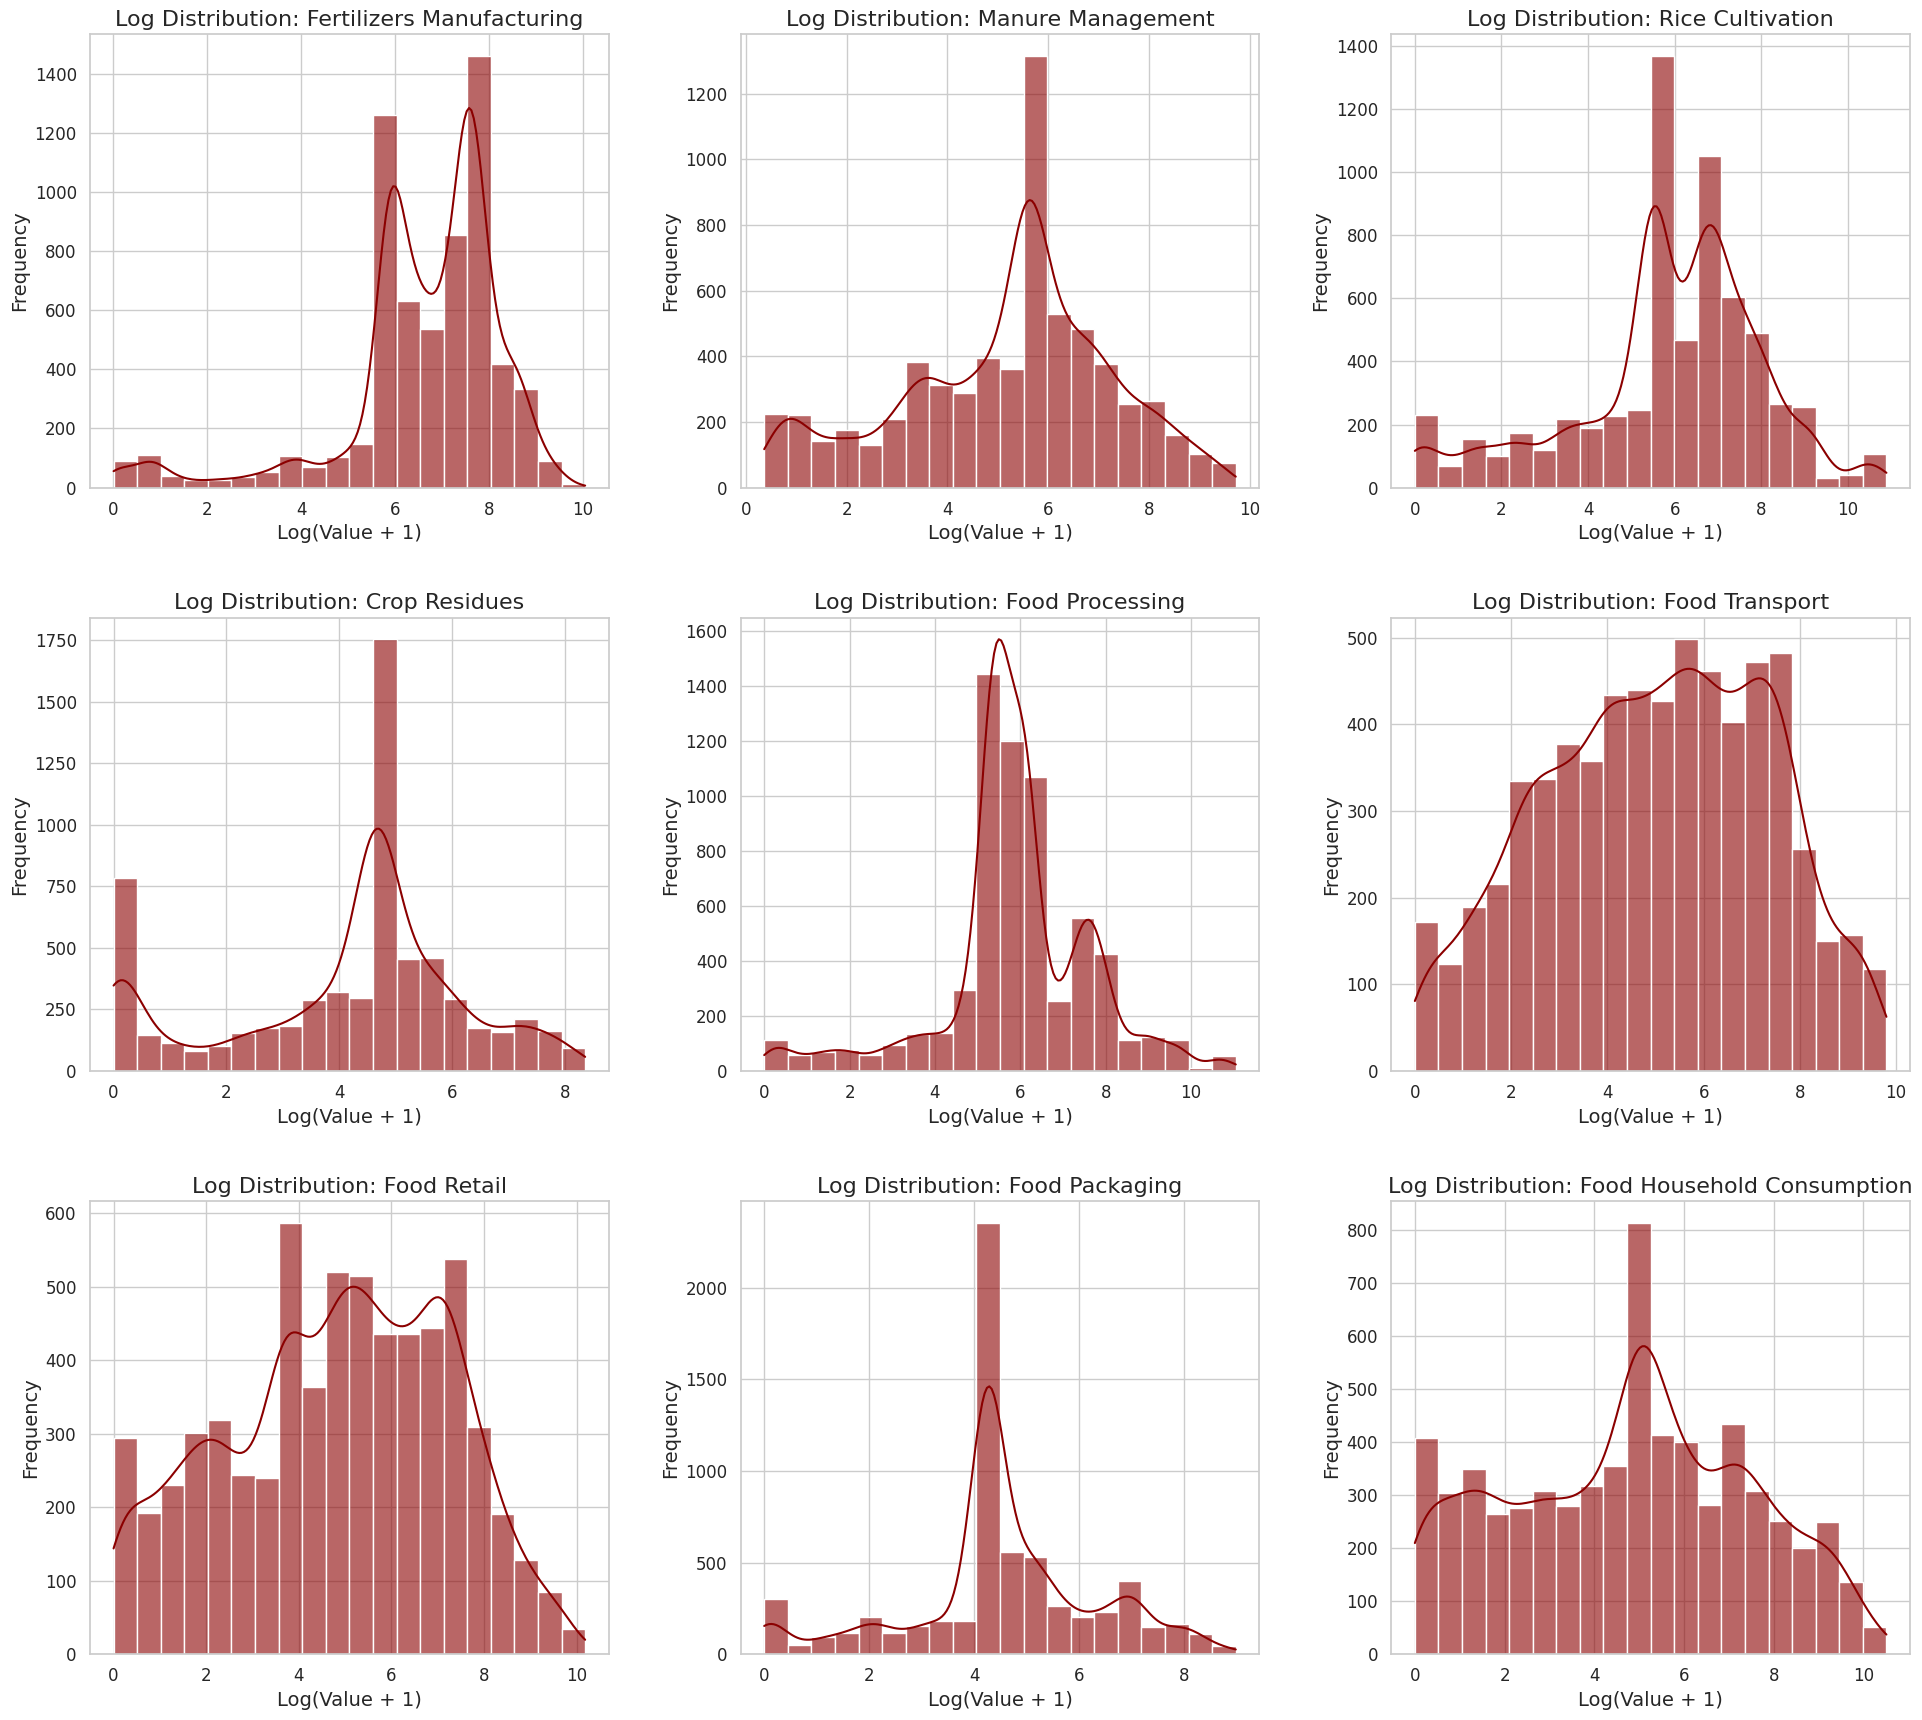

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Apply log transformation (log1p handles 0 values)
df_log = df.copy()
all_vars = production_group + supply_chain_group + [target_var]

for var in all_vars:
    df_log[var] = np.log1p(df[var])

# 2. Set up the 3x3 grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# 3. Create histograms for the log-transformed variables
for i, var in enumerate(all_vars):
    sns.histplot(df_log[var], bins=20, kde=True, color='darkred', ax=axes[i], alpha=0.6)

    axes[i].set_title(f'Log Distribution: {var}', fontsize=16)
    axes[i].set_xlabel('Log(Value + 1)', fontsize=14)
    axes[i].set_ylabel('Frequency', fontsize=14)
    axes[i].tick_params(axis='both', labelsize=12)

# 4. Final layout adjustment
plt.tight_layout(pad=3.0)
plt.show()

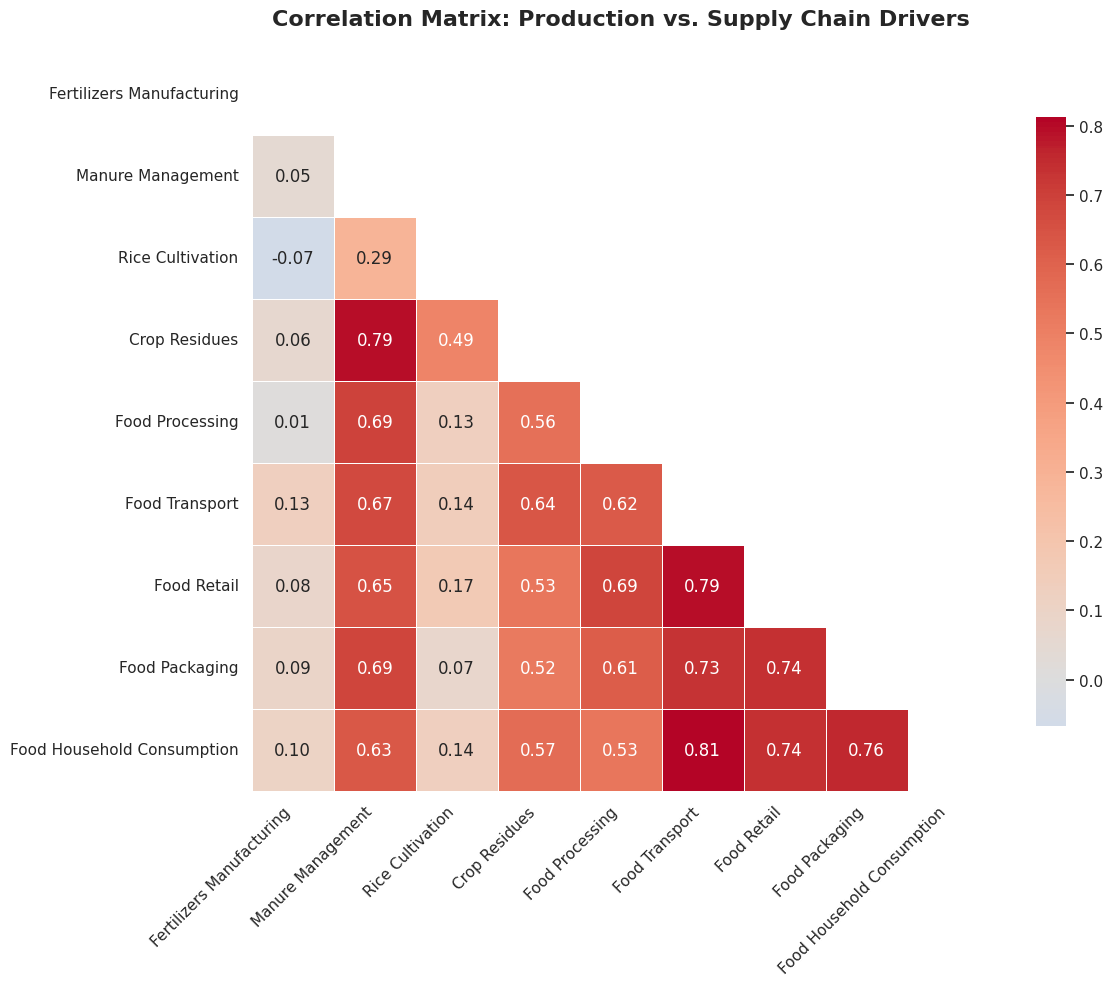

In [58]:
# --- 1. RE-ESTABLISH GROUPS ---
production_group = ['Fertilizers Manufacturing', 'Manure Management', 'Rice Cultivation', 'Crop Residues']
supply_chain_group = ['Food Processing', 'Food Transport', 'Food Retail', 'Food Packaging']
target_var = 'Food Household Consumption'
full_list = production_group + supply_chain_group + [target_var]

# --- 2. RE-CREATE CLEAN DATAFRAME ---
# We use the original 'df' and filter it specifically for this heatmap
# This ensures 'df_rf_clean' exists right before the correlation is calculated
df_rf_clean = df[full_list].dropna()

# --- 3. CALCULATE CORRELATION ---
corr_matrix = df_rf_clean.corr()

# --- 4. PLOTTING THE HEATMAP ---
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix: Production vs. Supply Chain Drivers',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

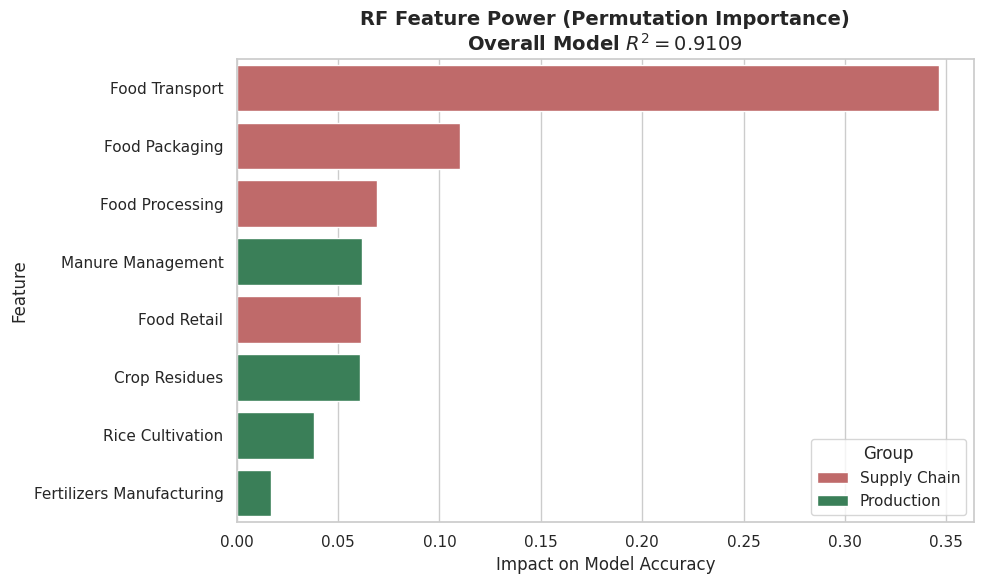

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# DATA PREP
production_group = ['Fertilizers Manufacturing', 'Manure Management', 'Rice Cultivation', 'Crop Residues']
supply_chain_group = ['Food Processing', 'Food Transport', 'Food Retail', 'Food Packaging']
all_features = production_group + supply_chain_group
target_var = 'Food Household Consumption'

# Cleaning
df_rf_clean = df[all_features + [target_var]].dropna()

# Even for RF, scaling helps interpretability when looking at Permutation Importance
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_rf_clean[all_features]), columns=all_features)
y = df_rf_clean[target_var]

# RANDOM FOREST
rf = RandomForestRegressor(n_estimators=100, max_depth=5, max_features='sqrt', random_state=42)
rf.fit(X_scaled, y)

# CALCULATE R-SQUARED & PERMUTATION IMPORTANCE

# This tells us how much of the total variance our model successfully captured
r2_score = rf.score(X_scaled, y)

result = permutation_importance(rf, X_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)

# Organize Results
df_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': result.importances_mean,
    'Group': ['Production']*4 + ['Supply Chain']*4
}).sort_values(by='Importance', ascending=False)

# INDIVIDUAL FEATURE POWER
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
palette = {'Production': '#2E8B57', 'Supply Chain': '#CD5C5C'}

sns.barplot(x='Importance', y='Feature', hue='Group', data=df_importance, palette=palette, dodge=False)

# R-squared
plt.title(f'RF Feature Power (Permutation Importance)\nOverall Model $R^2 = {r2_score:.4f}$',
          fontsize=14, fontweight='bold')
plt.xlabel('Impact on Model Accuracy')

plt.tight_layout()
plt.show()


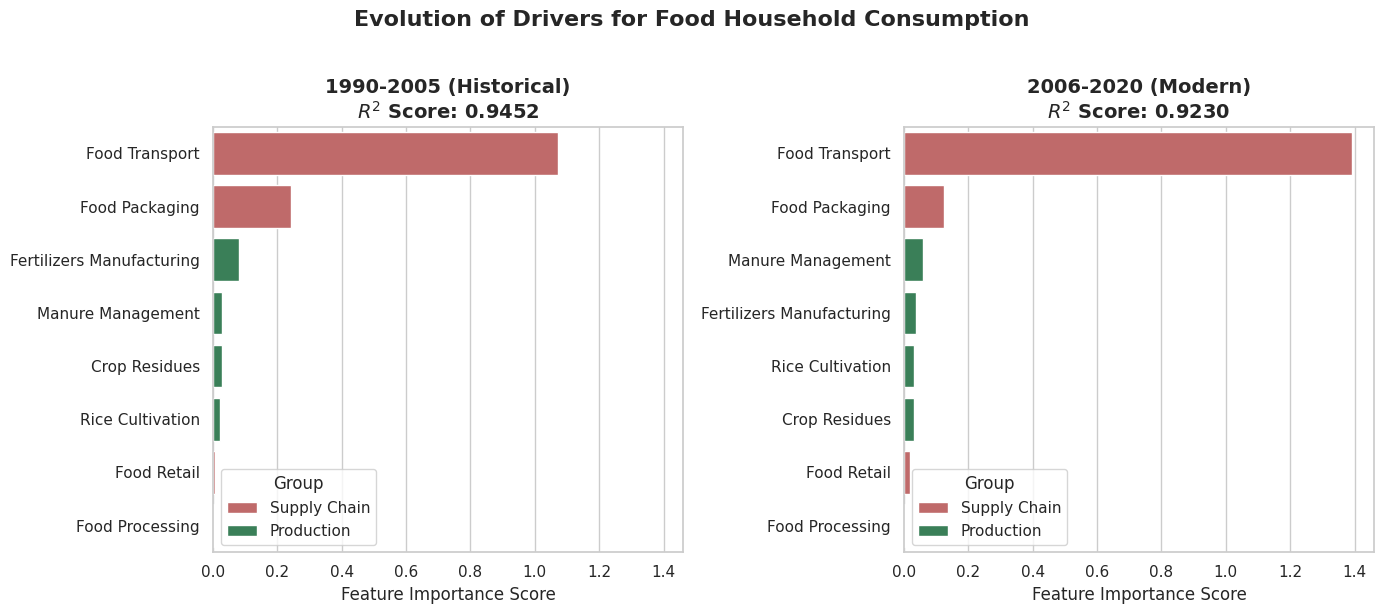

In [60]:
# --- 1. SETUP PERIODS ---
periods = [
    (1990, 2005, "1990-2005 (Historical)"),
    (2006, 2020, "2006-2020 (Modern)")
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
sns.set_theme(style="whitegrid")
palette = {'Production': '#2E8B57', 'Supply Chain': '#CD5C5C'}

# --- 2. LOOP THROUGH PERIODS ---
for i, (start, end, label) in enumerate(periods):
    # Filter by Year
    df_period = df[(df['Year'] >= start) & (df['Year'] <= end)].copy()

    # Cleaning
    df_clean = df_period[all_features + [target_var]].dropna()

    if len(df_clean) < 30:
        print(f"Skipping {label}: Insufficient data.")
        continue

    X = df_clean[all_features]
    y = df_clean[target_var]

    # Scaling for interpretability
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=all_features)

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_scaled, y)
    r2 = rf.score(X_scaled, y)

    # Calculate Permutation Importance
    result = permutation_importance(rf, X_scaled, y, n_repeats=10, random_state=42)

    df_imp = pd.DataFrame({
        'Feature': all_features,
        'Importance': result.importances_mean,
        'Group': ['Production']*4 + ['Supply Chain']*4
    }).sort_values(by='Importance', ascending=False)

    # --- 3. VISUALIZATION ---
    sns.barplot(ax=axes[i], x='Importance', y='Feature', hue='Group',
                data=df_imp, palette=palette, dodge=False)

    # Updated Titles and Labels
    axes[i].set_title(f'{label}\n$R^2$ Score: {r2:.4f}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Feature Importance Score', fontsize=12) # <--- Changed Label
    axes[i].set_ylabel('')

plt.suptitle('Evolution of Drivers for Food Household Consumption', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [61]:
# Ensure we use all available data without temporal or regional filtering
df_full_clean = df[all_features + [target_var]].dropna()

X = df_full_clean[all_features]
y = df_full_clean[target_var]

# Standardize features for stable importance calculation
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=all_features)

# --- 2. TRAIN RANDOM FOREST ---
rf_full = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_full.fit(X_scaled, y)

# --- 3. CALCULATE PERMUTATION IMPORTANCE ---
# result.importances_mean represents the drop in R^2 when a feature is shuffled
result = permutation_importance(rf_full, X_scaled, y, n_repeats=10, random_state=42)
importances = dict(zip(all_features, result.importances_mean))

# --- 4. CALCULATE GROUP INFLUENCE PERCENTAGES ---
prod_total_imp = sum([importances[f] for f in production_group])
supply_total_imp = sum([importances[f] for f in supply_chain_group])

# Total shared influence
total_influence = prod_total_imp + supply_total_imp

prod_percent = (prod_total_imp / total_influence) * 100
supply_percent = (supply_total_imp / total_influence) * 100

# --- 5. OUTPUT ---
print(f"--- Global Group Influence (Whole Sample) ---")
print(f"Production Sector: {prod_percent:.2f}%")
print(f"Supply Chain Sector: {supply_percent:.2f}%")

--- Global Group Influence (Whole Sample) ---
Production Sector: 11.65%
Supply Chain Sector: 88.35%


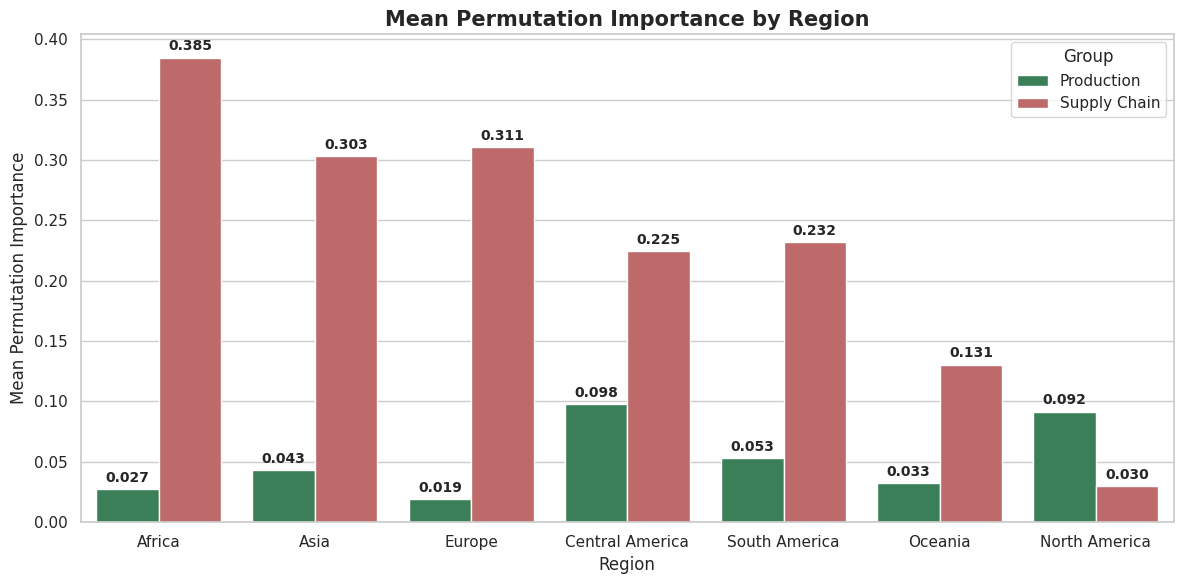

In [62]:
#  SETUP
production_group = ['Fertilizers Manufacturing', 'Manure Management', 'Rice Cultivation', 'Crop Residues']
supply_chain_group = ['Food Processing', 'Food Transport', 'Food Retail', 'Food Packaging']
all_features = production_group + supply_chain_group
target_var = 'Food Household Consumption'

# MACRO_REGION COLUMN
# We need to map countries to regions so the 'Macro_Region' column exists
region_map = {
    # --- NORTH AMERICA ---
    'United States of America': 'North America', 'United States': 'North America',
    'Canada': 'North America', 'Mexico': 'North America', 'Bermuda': 'North America',
    'Greenland': 'North America', 'Saint Pierre and Miquelon': 'North America',

    # --- CENTRAL AMERICA & CARIBBEAN ---
    'Costa Rica': 'Central America', 'Cuba': 'Central America', 'Dominican Republic': 'Central America',
    'El Salvador': 'Central America', 'Guatemala': 'Central America', 'Haiti': 'Central America',
    'Honduras': 'Central America', 'Jamaica': 'Central America', 'Nicaragua': 'Central America',
    'Panama': 'Central America', 'Puerto Rico': 'Central America', 'Bahamas': 'Central America',
    'Barbados': 'Central America', 'Trinidad and Tobago': 'Central America',

    # --- SOUTH AMERICA ---
    'Argentina': 'South America', 'Bolivia (Plurinational State of)': 'South America',
    'Brazil': 'South America', 'Chile': 'South America', 'Colombia': 'South America',
    'Ecuador': 'South America', 'Guyana': 'South America', 'Paraguay': 'South America',
    'Peru': 'South America', 'Suriname': 'South America', 'Uruguay': 'South America',
    'Venezuela (Bolivarian Republic of)': 'South America', 'Falkland Islands (Malvinas)': 'South America',

    # --- EUROPE ---
    'Albania': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe', 'Belgium': 'Europe',
    'Belgium-Luxembourg': 'Europe', 'Bosnia and Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Czechia': 'Europe', 'Czechoslovakia': 'Europe', 'Denmark': 'Europe',
    'Estonia': 'Europe', 'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe',
    'Greece': 'Europe', 'Hungary': 'Europe', 'Iceland': 'Europe', 'Ireland': 'Europe',
    'Italy': 'Europe', 'Latvia': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe',
    'Malta': 'Europe', 'Netherlands (Kingdom of the)': 'Europe', 'Norway': 'Europe',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Republic of Moldova': 'Europe', 'Romania': 'Europe',
    'Russian Federation': 'Europe', 'USSR': 'Europe', 'Serbia': 'Europe', 'Slovakia': 'Europe',
    'Slovenia': 'Europe', 'Spain': 'Europe', 'Sweden': 'Europe', 'Switzerland': 'Europe',
    'Ukraine': 'Europe', 'United Kingdom of Great Britain and Northern Ireland': 'Europe',
    'Yugoslav SFR': 'Europe',

    # --- ASIA ---
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bangladesh': 'Asia',
    'Bhutan': 'Asia', 'Brunei Darussalam': 'Asia', 'Cambodia': 'Asia', 'China': 'Asia',
    'China, mainland': 'Asia', 'China, Hong Kong SAR': 'Asia', 'China, Taiwan Province of': 'Asia',
    'Georgia': 'Asia', 'India': 'Asia', 'Indonesia': 'Asia', 'Iran (Islamic Republic of)': 'Asia',
    'Iraq': 'Asia', 'Israel': 'Asia', 'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia',
    'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', "Lao People's Democratic Republic": 'Asia',
    'Lebanon': 'Asia', 'Malaysia': 'Asia', 'Mongolia': 'Asia', 'Myanmar': 'Asia', 'Nepal': 'Asia',
    "Democratic People's Republic of Korea": 'Asia', 'Oman': 'Asia', 'Pakistan': 'Asia',
    'Philippines': 'Asia', 'Qatar': 'Asia', 'Republic of Korea': 'Asia', 'Saudi Arabia': 'Asia',
    'Singapore': 'Asia', 'Sri Lanka': 'Asia', 'Syrian Arab Republic': 'Asia', 'Tajikistan': 'Asia',
    'Thailand': 'Asia', 'Turkey': 'Asia', 'Turkmenistan': 'Asia', 'United Arab Emirates': 'Asia',
    'Uzbekistan': 'Asia', 'Viet Nam': 'Asia', 'Yemen': 'Asia',

    # --- AFRICA ---
    'Algeria': 'Africa', 'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cabo Verde': 'Africa', 'Cameroon': 'Africa',
    'Central African Republic': 'Africa', 'Chad': 'Africa', 'Congo': 'Africa',
    'Democratic Republic of the Congo': 'Africa', 'Djibouti': 'Africa', 'Egypt': 'Africa',
    'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa', 'Eswatini': 'Africa', 'Ethiopia': 'Africa',
    'Gabon': 'Africa', 'Gambia': 'Africa', 'Ghana': 'Africa', 'Guinea': 'Africa', 'Ivory Coast': 'Africa',
    'Kenya': 'Africa', 'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa', 'Madagascar': 'Africa',
    'Malawi': 'Africa', 'Mali': 'Africa', 'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa',
    'Mozambique': 'Africa', 'Namibia': 'Africa', 'Niger': 'Africa', 'Nigeria': 'Africa', 'Rwanda': 'Africa',
    'Senegal': 'Africa', 'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'South Sudan': 'Africa', 'Sudan': 'Africa', 'Togo': 'Africa',
    'Tunisia': 'Africa', 'Uganda': 'Africa', 'United Republic of Tanzania': 'Africa',
    'Zambia': 'Africa', 'Zimbabwe': 'Africa',

    # --- OCEANIA ---
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'New Zealand': 'Oceania', 'Papua New Guinea': 'Oceania',
    'Solomon Islands': 'Oceania', 'Vanuatu': 'Oceania', 'New Caledonia': 'Oceania', 'French Polynesia': 'Oceania'
}

# Automatically find the country column (usually 'Country' or 'Entity' or 'Area')
country_col = next((c for c in ['Country', 'Entity', 'Area'] if c in df.columns), None)
if country_col:
    df['Macro_Region'] = df[country_col].map(region_map)
else:
    # Fallback if no country column found: use a dummy or skip
    df['Macro_Region'] = 'Global'


# Now 'Macro_Region' exists, so this line won't crash
df_rf_clean = df[all_features + [target_var, 'Macro_Region']].dropna()

# REGIONAL RF ANALYSIS
regional_rf_results = []
macro_regions = df_rf_clean['Macro_Region'].unique()

for reg in macro_regions:
    sub_df = df_rf_clean[df_rf_clean['Macro_Region'] == reg].copy()

    # RF needs a minimum number of rows to be statistically valid
    if len(sub_df) < 20:
        continue

    X = sub_df[all_features]
    y = sub_df[target_var]

    # RF
    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X, y)

    # Calculate Permutation Importance
    perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42)

    # Map importance back to groups and take the MEAN to avoid group-size bias
    importances = dict(zip(all_features, perm.importances_mean))
    prod_power = np.mean([importances[f] for f in production_group])
    supply_power = np.mean([importances[f] for f in supply_chain_group])

    regional_rf_results.append({'Region': reg, 'Group': 'Production', 'Power': prod_power})
    regional_rf_results.append({'Region': reg, 'Group': 'Supply Chain', 'Power': supply_power})

# VISUALIZATION
results_rf_df = pd.DataFrame(regional_rf_results)

if not results_rf_df.empty:
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    # Sort regions by total combined predictive power
    sort_order = results_rf_df.groupby('Region')['Power'].sum().sort_values(ascending=False).index

    ax = sns.barplot(
        data=results_rf_df, x='Region', y='Power', hue='Group',
        order=sort_order, palette={'Production': '#2E8B57', 'Supply Chain': '#CD5C5C'}
    )

    plt.title('Mean Permutation Importance by Region', fontsize=15, fontweight='bold')
    plt.ylabel('Mean Permutation Importance')

    # Add data labels
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, xytext=(0, 8), textcoords='offset points', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No regions met the sample size threshold (N=20) for RF analysis.")

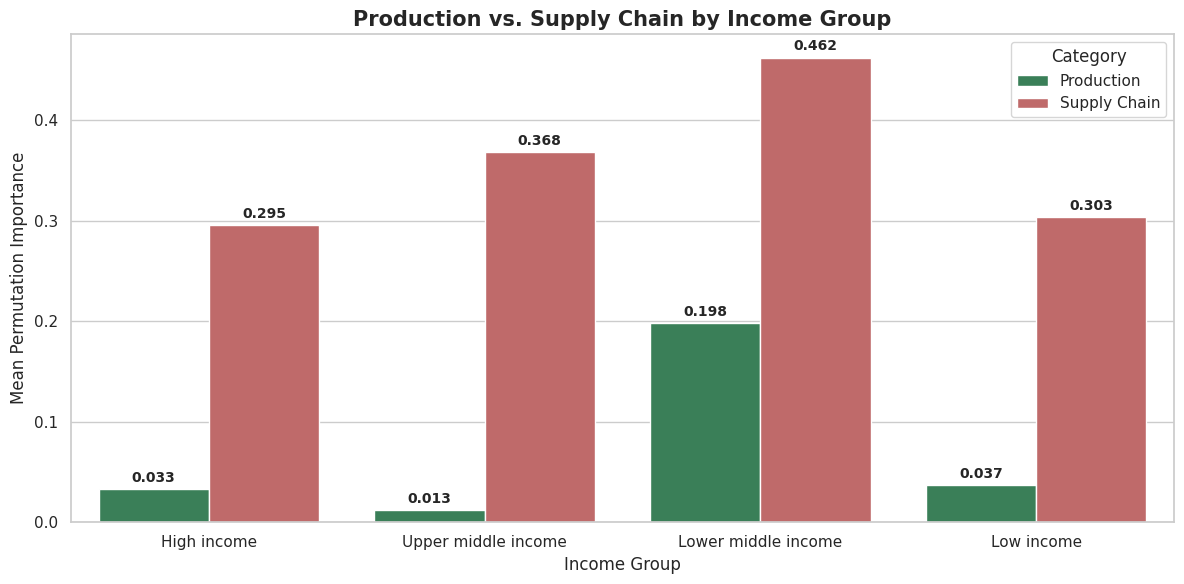

In [63]:
# SETUP
production_group = ['Fertilizers Manufacturing', 'Manure Management', 'Rice Cultivation', 'Crop Residues']
supply_chain_group = ['Food Processing', 'Food Transport', 'Food Retail', 'Food Packaging']
all_features = production_group + supply_chain_group
target_var = 'Food Household Consumption'

# INTEGRATE INCOME MAPPING
# Your provided mapping for specific/historical entities
income_group2 = {
    # --- HIGH INCOME ---
    'Australia': "High income", 'Austria': "High income", 'Belgium': "High income", 'Canada': "High income",
    'Chile': "High income", 'Croatia': "High income", 'Cyprus': "High income", 'Czechia': "High income",
    'Denmark': "High income", 'Estonia': "High income", 'Finland': "High income", 'France': "High income",
    'Germany': "High income", 'Greece': "High income", 'Hungary': "High income", 'Iceland': "High income",
    'Ireland': "High income", 'Israel': "High income", 'Italy': "High income", 'Japan': "High income",
    'Kuwait': "High income", 'Latvia': "High income", 'Lithuania': "High income", 'Luxembourg': "High income",
    'Malta': "High income", 'Netherlands': "High income", 'New Zealand': "High income", 'Norway': "High income",
    'Oman': "High income", 'Panama': "High income", 'Poland': "High income", 'Portugal': "High income",
    'Qatar': "High income", 'Saudi Arabia': "High income", 'Seychelles': "High income", 'Singapore': "High income",
    'Slovenia': "High income", 'Spain': "High income", 'Sweden': "High income", 'Switzerland': "High income",
    'United Arab Emirates': "High income", 'Uruguay': "High income",
    # Territories & Historical (High)
    'Anguilla': "High income", 'Bahamas': "High income", 'Belgium-Luxembourg': "High income",
    'Bermuda': "High income", 'British Virgin Islands': "High income", 'Cayman Islands': "High income",
    'Cook Islands': "High income", 'Czechoslovakia': "High income", 'Falkland Islands (Malvinas)': "High income",
    'Faroe Islands': "High income", 'French Polynesia': "High income", 'Gibraltar': "High income",
    'Greenland': "High income", 'Guadeloupe': "High income", 'Guam': "High income", 'Holy See': "High income",
    'Isle of Man': "High income", 'Martinique': "High income", 'Monaco': "High income", 'Montserrat': "High income",
    'Netherlands (Kingdom of the)': "High income", 'Netherlands Antilles (former)': "High income",
    'New Caledonia': "High income", 'Puerto Rico': "High income", 'Republic of Korea': "High income",
    'Saint Kitts and Nevis': "High income", 'Saint Pierre and Miquelon': "High income", 'Slovakia': "High income",
    'USSR': "High income", 'United Kingdom of Great Britain and Northern Ireland': "High income",
    'United States Virgin Islands': "High income", 'United States of America': "High income",
    'Wallis and Futuna Islands': "High income",

    # --- UPPER MIDDLE INCOME ---
    'Albania': "Upper middle income", 'Argentina': "Upper middle income", 'Armenia': "Upper middle income",
    'Azerbaijan': "Upper middle income", 'Belarus': "Upper middle income", 'Botswana': "Upper middle income",
    'Brazil': "Upper middle income", 'Bulgaria': "Upper middle income", 'China': "Upper middle income",
    'China, mainland': "Upper middle income", 'China, Hong Kong SAR': "Upper middle income",
    'China, Macao SAR': "Upper middle income", 'China, Taiwan Province of': "Upper middle income",
    'Colombia': "Upper middle income", 'Costa Rica': "Upper middle income", 'Dominica': "Upper middle income",
    'Dominican Republic': "Upper middle income", 'Equatorial Guinea': "Upper middle income",
    'Fiji': "Upper middle income", 'Gabon': "Upper middle income", 'Georgia': "Upper middle income",
    'Grenada': "Upper middle income", 'Guatemala': "Upper middle income", 'Guyana': "Upper middle income",
    'Iran (Islamic Republic of)': "Upper middle income", 'Iraq': "Upper middle income",
    'Jamaica': "Upper middle income", 'Jordan': "Upper middle income", 'Kazakhstan': "Upper middle income",
    'Lebanon': "Upper middle income", 'Libya': "Upper middle income", 'Malaysia': "Upper middle income",
    'Maldives': "Upper middle income", 'Mauritius': "Upper middle income", 'Mexico': "Upper middle income",
    'Montenegro': "Upper middle income", 'Namibia': "Upper middle income", 'Paraguay': "Upper middle income",
    'Peru': "Upper middle income", 'Republic of Moldova': "Upper middle income", 'Romania': "Upper middle income",
    'Russian Federation': "Upper middle income", 'Saint Lucia': "Upper middle income",
    'Saint Vincent and the Grenadines': "Upper middle income", 'Serbia': "Upper middle income",
    'Serbia and Montenegro': "Upper middle income", 'South Africa': "Upper middle income",
    'Suriname': "Upper middle income", 'Thailand': "Upper middle income", 'Turkey': "Upper middle income",
    'Turkmenistan': "Upper middle income", 'Venezuela (Bolivarian Republic of)': "Upper middle income",
    'Yugoslav SFR': "Upper middle income",

    # --- LOWER MIDDLE INCOME ---
    'Algeria': "Lower middle income", 'Angola': "Lower middle income", 'Bangladesh': "Lower middle income",
    'Benin': "Lower middle income", 'Bhutan': "Lower middle income", 'Bolivia (Plurinational State of)': "Lower middle income",
    'Cabo Verde': "Lower middle income", 'Cambodia': "Lower middle income", 'Cameroon': "Lower middle income",
    'Comoros': "Lower middle income", 'Congo': "Lower middle income", "Cote d'Ivoire": "Lower middle income",
    'Djibouti': "Lower middle income", 'Egypt': "Lower middle income", 'El Salvador': "Lower middle income",
    'Eswatini': "Lower middle income", 'Ghana': "Lower middle income", 'Honduras': "Lower middle income",
    'India': "Lower middle income", 'Indonesia': "Lower middle income", 'Kenya': "Lower middle income",
    'Kyrgyzstan': "Lower middle income", "Lao People's Democratic Republic": "Lower middle income",
    'Lesotho': "Lower middle income", 'Mauritania': "Lower middle income",
    'Micronesia (Federated States of)': "Lower middle income", 'Mongolia': "Lower middle income",
    'Morocco': "Lower middle income", 'Myanmar': "Lower middle income", 'Nepal': "Lower middle income",
    'Nicaragua': "Lower middle income", 'Nigeria': "Lower middle income", 'Niue': "Lower middle income",
    'Pakistan': "Lower middle income", 'Palestine': "Lower middle income", 'Papua New Guinea': "Lower middle income",
    'Philippines': "Lower middle income", 'Saint Helena, Ascension and Tristan da Cunha': "Lower middle income",
    'Samoa': "Lower middle income", 'Sao Tome and Principe': "Lower middle income", 'Senegal': "Lower middle income",
    'Solomon Islands': "Lower middle income", 'Sri Lanka': "Lower middle income", 'Tajikistan': "Lower middle income",
    'Tokelau': "Lower middle income", 'Tunisia': "Lower middle income", 'Ukraine': "Lower middle income",
    'United Republic of Tanzania': "Lower middle income", 'Uzbekistan': "Lower middle income",
    'Vanuatu': "Lower middle income", 'Viet Nam': "Lower middle income", 'Western Sahara': "Lower middle income",
    'Zambia': "Lower middle income", 'Zimbabwe': "Lower middle income",

    # --- LOW INCOME ---
    'Afghanistan': "Low income", 'Burkina Faso': "Low income", 'Burundi': "Low income",
    'Central African Republic': "Low income", 'Chad': "Low income", "Democratic People's Republic of Korea": "Low income",
    'Democratic Republic of the Congo': "Low income", 'Eritrea': "Low income", 'Ethiopia': "Low income",
    'Ethiopia PDR': "Low income", 'Gambia': "Low income", 'Guinea': "Low income", 'Guinea-Bissau': "Low income",
    'Haiti': "Low income", 'Liberia': "Low income", 'Madagascar': "Low income", 'Malawi': "Low income",
    'Mali': "Low income", 'Mayotte': "Low income", 'Mozambique': "Low income", 'Niger': "Low income",
    'Pacific Islands Trust Territory': "Low income", 'Rwanda': "Low income", 'Sierra Leone': "Low income",
    'Somalia': "Low income", 'South Sudan': "Low income", 'Sudan': "Low income", 'Sudan (former)': "Low income",
    'Syrian Arab Republic': "Low income", 'Togo': "Low income", 'Uganda': "Low income", 'Yemen': "Low income"
}

# Identify the entity column and map
country_col = next((c for c in ['Country', 'Entity', 'Area'] if c in df.columns), None)
df['Income_Group'] = df[country_col].map(income_group2)


# Filter for finite values and drop rows where the income group is unknown
df_rf_clean = df[all_features + [target_var, 'Income_Group']].dropna()

# RF ANALYSIS PER INCOME GROUP
income_rf_results = []
groups = df_rf_clean['Income_Group'].unique()

for group in groups:
    sub_df = df_rf_clean[df_rf_clean['Income_Group'] == group].copy()

    if len(sub_df) < 20:
        continue

    X = sub_df[all_features]
    y = sub_df[target_var]

    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X, y)

    # Calculate R-squared for context
    r2_score = rf.score(X, y)

    # Permutation Importance (Predictive Power)
    perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42)

    importances = dict(zip(all_features, perm.importances_mean))
    prod_power = np.mean([importances[f] for f in production_group])
    supply_power = np.mean([importances[f] for f in supply_chain_group])

    income_rf_results.append({'Income Group': group, 'Category': 'Production', 'Power': prod_power, 'R2': r2_score})
    income_rf_results.append({'Income Group': group, 'Category': 'Supply Chain', 'Power': supply_power, 'R2': r2_score})

# VISUALIZATION
results_df = pd.DataFrame(income_rf_results)

if not results_df.empty:
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    # Order by development level for logical reading
    order = ["High income", "Upper middle income", "Lower middle income", "Low income"]
    actual_order = [o for o in order if o in results_df['Income Group'].unique()]

    ax = sns.barplot(data=results_df, x='Income Group', y='Power', hue='Category',
                     order=actual_order, palette={'Production': '#2E8B57', 'Supply Chain': '#CD5C5C'})

    plt.title('Production vs. Supply Chain by Income Group', fontsize=15, fontweight='bold')
    plt.ylabel('Mean Permutation Importance')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, xytext=(0, 8), textcoords='offset points', fontweight='bold')

    plt.tight_layout()
    plt.show()